In [1]:
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
from tqdm import tqdm
np.random.seed(22)

In [2]:
plt.rc('text', usetex = False)

In [3]:
syn = frz.read_profile('/dat/xenosh/muram_plage_pore/26000/stokes.bin')

In [4]:
sim = frz.read_model('/dat/xenosh/muram_plage_pore/26000/muram_026000_nx1536_ny1536_nz240_d605.bin')

In [5]:
atm = fits.open('/dat/xenosh/sharing/new_10s_tau.fits')[0].data

In [ ]:
#tau,tem,pg,rho,vmic,vz,bx,by,bz

In [123]:
sim_inv = frz.read_model('/dat/xenosh/muram_plage_pore/20000/test3/2/out_out_valc_nx192_ny192_nz64_dz12.bin')

In [6]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim.tem.shape[0]
ny = sim.tem.shape[1]
nz = tau_common.shape[0]
T= np.zeros((nx,ny,nz))
P= np.zeros((nx,ny,nz))
Bx= np.zeros((nx,ny,nz))
By= np.zeros((nx,ny,nz))
Bz= np.zeros((nx,ny,nz))
Vz= np.zeros((nx,ny,nz))
Bh = np.zeros((nx,ny,nz))
a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        P[i,j,:] = 10 ** a
        Bx[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bx[i,j,::-1])
        By[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.by[i,j,::-1])
        Bz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bz[i,j,::-1])
        Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)

In [7]:
B = np.sqrt(Bz**2+Bh**2)

In [8]:
tau_common = tau_common[::-1]

In [9]:

T[:,:,:] = T[:,:,::-1]
P[:,:,:] = P[:,:,::-1]
Bx[:,:,:] = Bx[:,:,::-1]
By[:,:,:] = By[:,:,::-1]
Bz[:,:,:] = Bz[:,:,::-1]
Vz[:,:,:] = Vz[:,:,::-1]
Bh[:,:,:] = Bh[:,:,::-1]
B[:,:,:] = B[:,:,::-1]

In [129]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim_inv.tem.shape[0]
ny = sim_inv.tem.shape[1]
nz = tau_common.shape[0]
#T= np.zeros((nx,ny,nz))
#P= np.zeros((nx,ny,nz))
Bx1= np.zeros((nx,ny,nz))
By1= np.zeros((nx,ny,nz))
Bz1= np.zeros((nx,ny,nz))
#Vz= np.zeros((nx,ny,nz))
#Bh = np.zeros((nx,ny,nz))
#a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        #T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        #a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        #P[i,j,:] = 10 ** a
        Bx1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bx[i,j,::-1])
        By1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.by[i,j,::-1])
        Bz1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bz[i,j,::-1])
        #Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        #Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)

In [130]:
B1 = np.sqrt(Bz1**2+Bx1**2+By1**2)

In [131]:
tau_common = tau_common[::-1]
Bx1[:,:,:] = Bx1[:,:,::-1]
By1[:,:,:] = By1[:,:,::-1]
Bz1[:,:,:] = Bz1[:,:,::-1]
B1[:,:,:] = B1[:,:,::-1]

## core, canopy, qs, oppo

In [ ]:
# sim

In [10]:
c1 = B[:,:,10]>1000
c2 = B[:,:,10]<100
core = np.argwhere(c1)
qs = np.argwhere(c2)

In [11]:
c3 = B[:,:,30] > 300
c4 = B[:,:,30] - B[:,:,10] > 50
c5 = B[:,:,10] < 1000
canopy = np.argwhere(c5 & c3 & c4)

In [12]:
c6 = Bz[:,:,15] < -50
c7 = B[:,:,30] > 300
oppo = np.argwhere(c6 & c7)

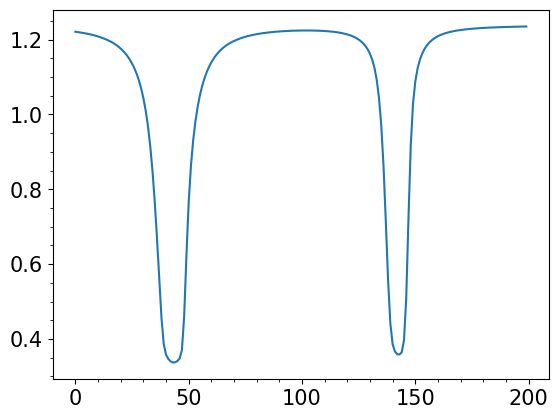

In [32]:
plt.plot(syn.stki[:,100,100])

In [13]:
c8 = B[:,:,30] > 300
c9 = syn.stki[100,:,:]/np.mean(syn.stki[100,:,:]) > 0.85
plage = np.argwhere(c8)

In [13]:
print(qs.shape)
print(core.shape)
print(canopy.shape)
print(oppo.shape)

(1234927, 2)
(476428, 2)
(609618, 2)
(103382, 2)


In [36]:
print(oppo.shape)

(127418, 2)


In [39]:
oppo.shape[0]/1536/1536

0.05687501695421007

1.2581707176021546

In [ ]:
# obs

In [14]:
t = 20

In [15]:
c1 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2)>900
c2 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2)<200
core_o = np.argwhere(c1)
qs_o = np.argwhere(c2)

In [16]:
c3 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) > 300
c4 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) - np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2) > 50
c5 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2) < 1000
canopy_o = np.argwhere(c5 & c3 & c4)

In [17]:
c6 = atm[t,8,:,:,15] > 50
c7 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) > 300
oppo_o = np.argwhere(c6 & c7)

In [18]:
plage_o = np.argwhere(c7)

In [18]:
print(qs_o.shape)
print(core_o.shape)
print(canopy_o.shape)
print(oppo_o.shape)

(6325, 2)
(3575, 2)
(2664, 2)
(229, 2)


In [16]:
print(qs_o.shape)
print(core_o.shape)
print(canopy_o.shape)
print(oppo_o.shape)

(6668, 2)
(3576, 2)
(3205, 2)
(591, 2)


In [19]:
oppo.shape[0]/129/116

6.908714247527399

### example profile of opposite polarity

In [19]:
np.random.randint(oppo.shape[0])

24932

In [58]:
syn.stki[:,x,y].shape

(200,)

439.31025803208945


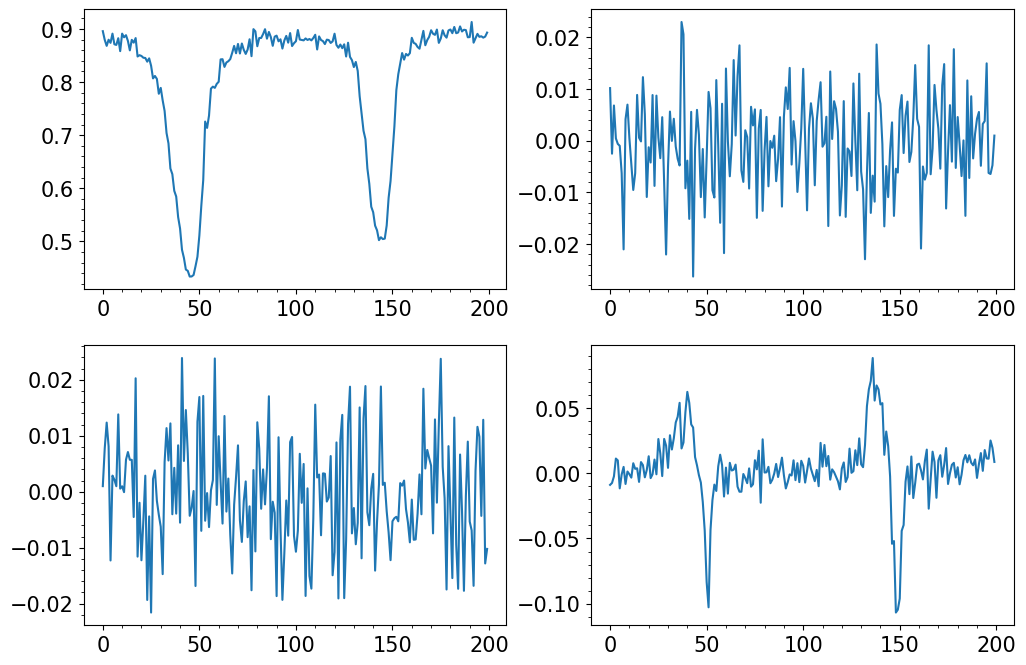

In [14]:
n = np.random.randint(oppo.shape[0])
x = oppo[n,0]
y = oppo[n,1]
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.plot(syn.stki[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(222)
plt.plot(syn.stkq[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(223)
plt.plot(syn.stku[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(224)
plt.plot(syn.stkv[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
print(Bz[oppo[n,0],oppo[n,1],30])

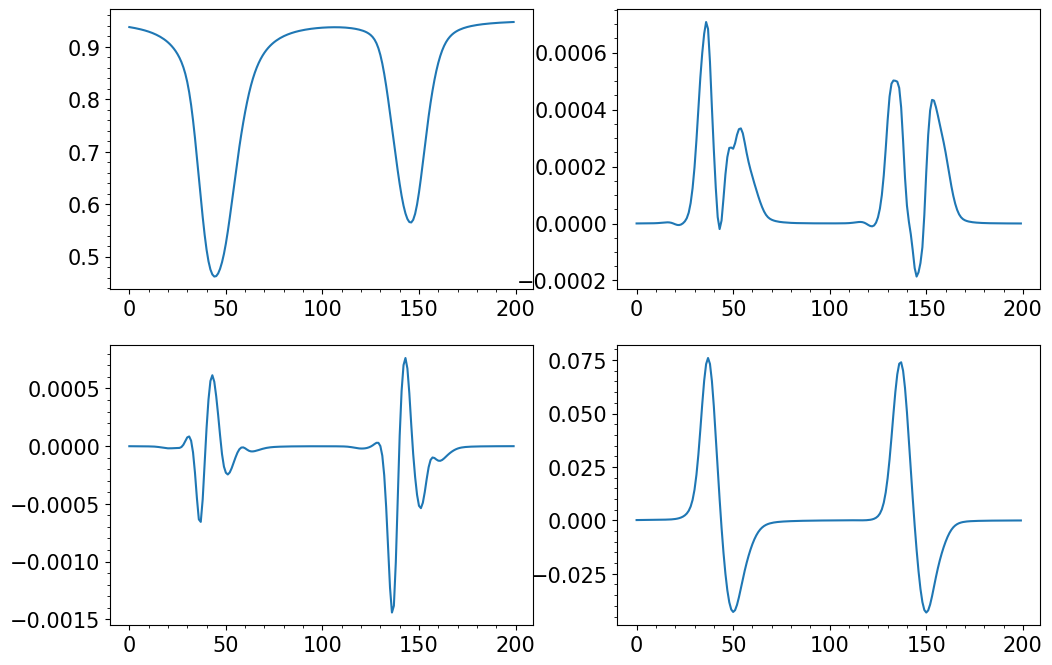

In [45]:
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.plot(np.mean(syn.stki[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(222)
plt.plot(np.mean(syn.stkq[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(223)
plt.plot(np.mean(syn.stku[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(224)
plt.plot(np.mean(syn.stkv[:,oppo[:,0],oppo[:,1]],axis=1))

## T

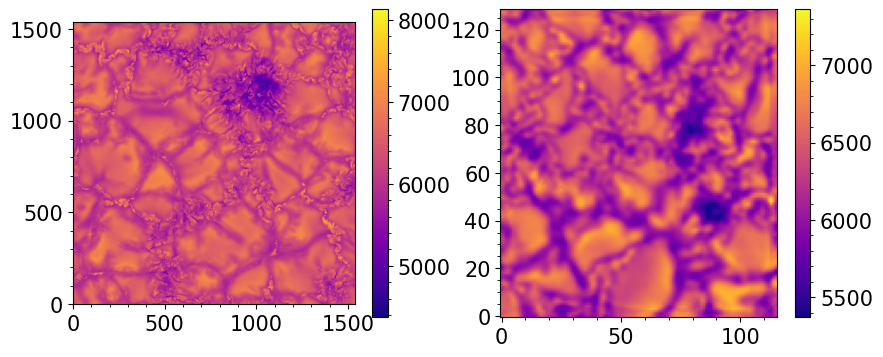

In [87]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(T[:,:,30].T,origin='lower',cmap='plasma')
plt.colorbar()
plt.subplot(122)
plt.imshow(atm[1,1,:,:,10].T,origin='lower',cmap='plasma')
plt.colorbar()

In [58]:
6300/6.5

969.2307692307693

In [59]:
4550/6.5

700.0

In [69]:
oppo.shape

(103382, 2)

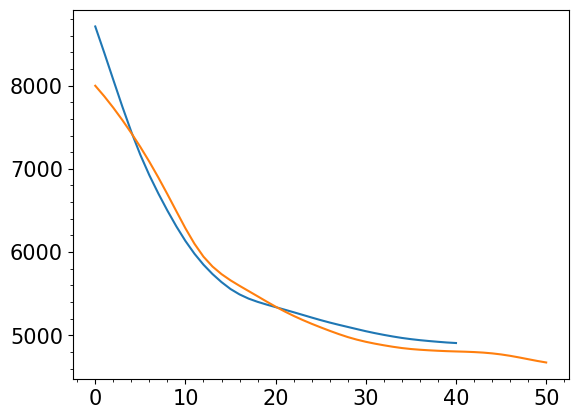

In [77]:
plt.plot(np.mean(T[oppo[:,0],oppo[:,1],:],axis=0))
plt.plot(np.mean(atm[20,1,oppo_o[:,0],oppo_o[:,1],:],axis=0))

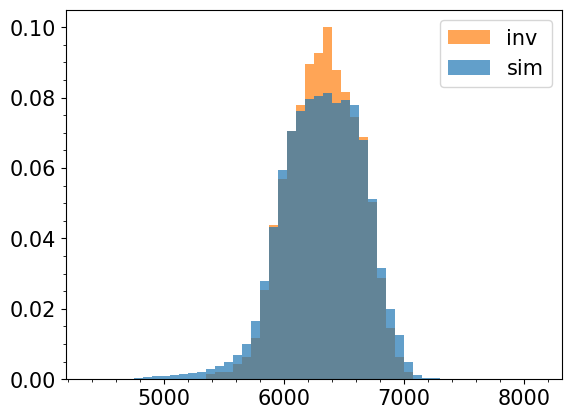

In [30]:
plt.hist([T[:,:,30].flatten(),atm[1,1,:,:,10].flatten()],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/1536/1536]*1536*1536,[1/129/116]*129*116])
plt.legend()

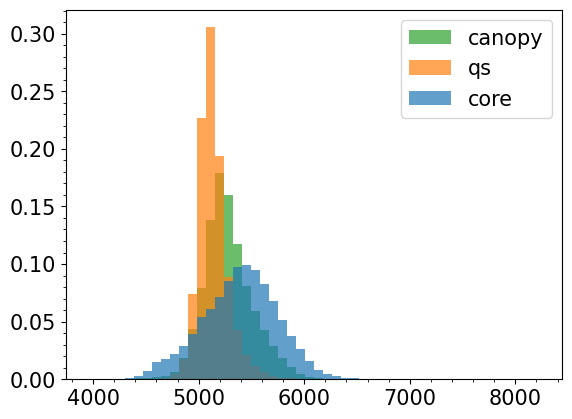

In [104]:
plt.hist([T[core[:,0],core[:,1],20],T[qs[:,0],qs[:,1],20],T[canopy[:,0],canopy[:,1],20]],bins=50,histtype='stepfilled',label=['core','qs','canopy'],alpha=0.7
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/qs.shape[0]]*qs.shape[0],[1/canopy.shape[0]]*canopy.shape[0]])
plt.legend()

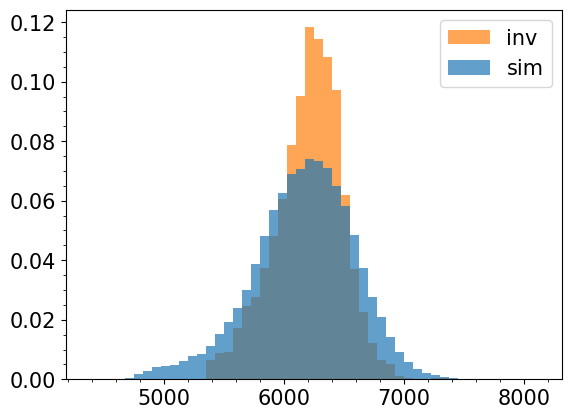

In [ ]:
plt.hist([T[core[:,0],core[:,1],10],atm[1,1,core_o[:,0],core_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()

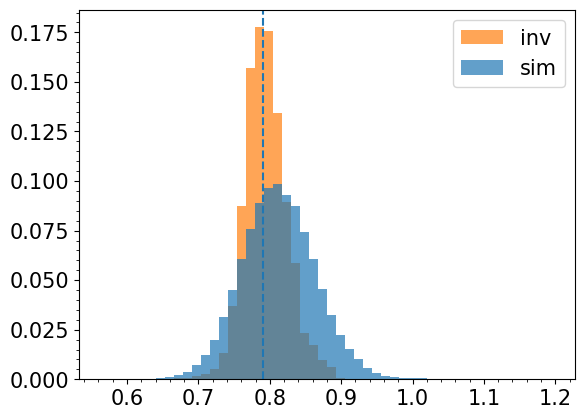

In [156]:
plt.hist([T[core[:,0],core[:,1],33]/T[core[:,0],core[:,1],10],atm[1,1,core_o[:,0],core_o[:,1],33]/atm[1,1,core_o[:,0],core_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()
plt.axvline(0.79,ls='--')

In [155]:
np.mean(T[core[:,0],core[:,1],33]/T[core[:,0],core[:,1],10])

0.8130203181050891

(4000.0, 9000.0)

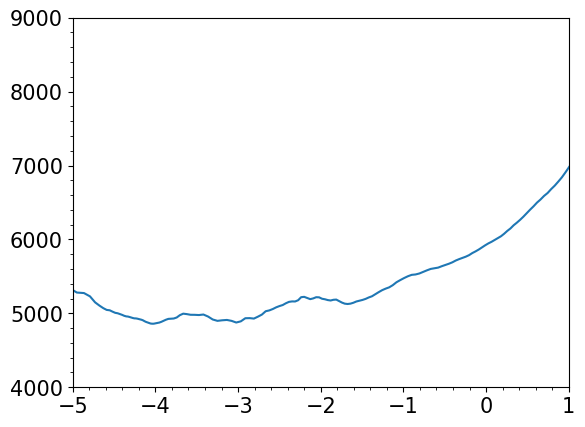

In [86]:
n = np.random.randint(core.shape[0])
x = core[n,0]
y = core[n,1]
plt.plot(sim.tau[x,y,:],sim.tem[x,y,:])
plt.xlim([-5,1])
plt.ylim([4000,9000])

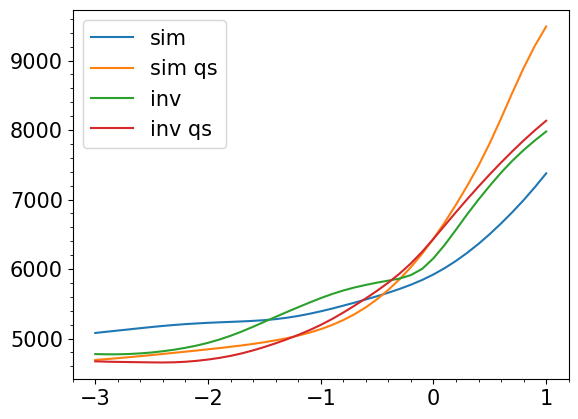

In [ ]:
plt.plot(tau_common,np.mean(T[450:500,350:400,:],axis=(0,1)),label='sim')
plt.plot(tau_common,np.mean(T[qs[:,0],qs[:,1],:],axis=0),label='sim qs')
plt.plot(tau_common,np.mean(atm[1,1,40:50,70:80,:41],axis=(0,1)),label='inv')
plt.plot(tau_common,np.mean(atm[1,1,qs_o[:,0],qs_o[:,1],:41],axis=0),label='inv qs')
plt.legend()

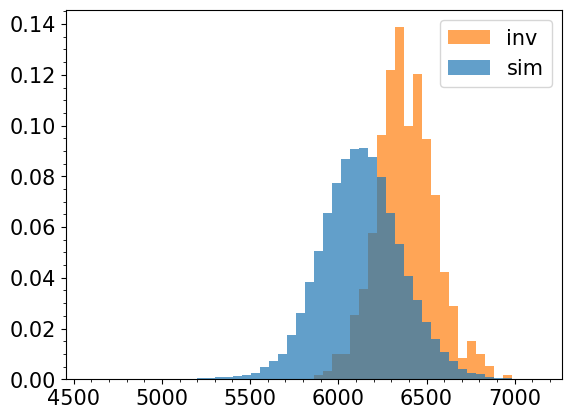

In [27]:
plt.hist([T[oppo[:,0],oppo[:,1],10],atm[1,1,oppo_o[:,0],oppo_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/oppo.shape[0]]*oppo.shape[0],[1/oppo_o.shape[0]]*oppo_o.shape[0]])
plt.legend()

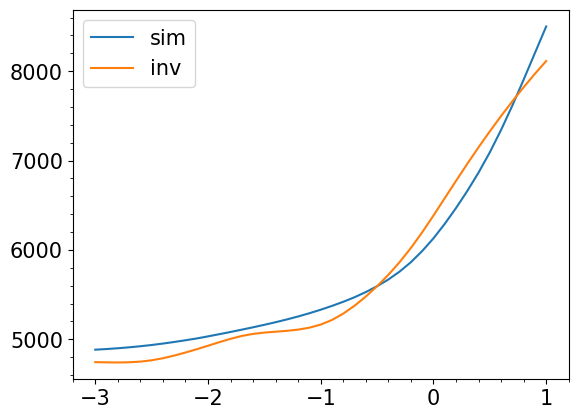

In [16]:
plt.plot(tau_common,np.mean(T[oppo[:,0],oppo[:,1],:],axis=0),label='sim')
plt.plot(tau_common,np.mean(atm[1,1,oppo_o[:,0],oppo_o[:,1],:41],axis=0),label='inv')
plt.legend()

## B

In [ ]:
slice = 

(0.0, 250.0)

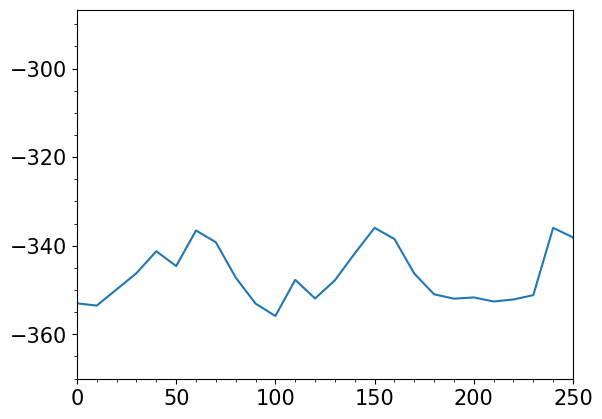

In [14]:
t = np.arange(145)*10
plt.plot(t, np.mean(atm[:,8,:,:,10],axis=(1,2)))
plt.xlim([0,250])

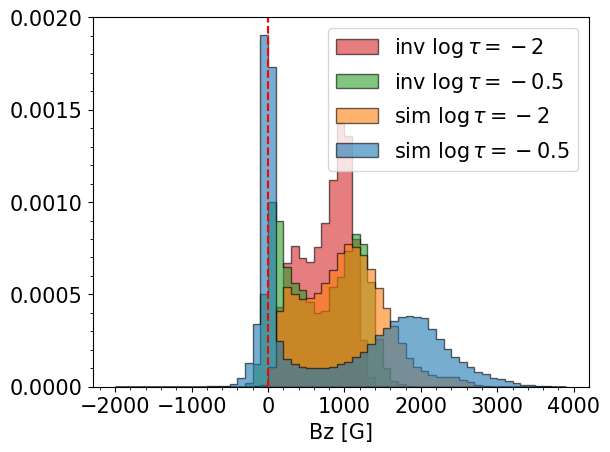

In [ ]:
xbins = np.arange(-2000,4000,100)
plt.hist([Bz[plage[:,0],plage[:,1],15].flatten(),Bz[plage[:,0],plage[:,1],30].flatten(),-atm[20,8,plage_o[:,0],plage_o[:,1],15],-atm[20,8,plage_o[:,0],plage_o[:,1],30]],bins=xbins,histtype='stepfilled',alpha=0.6,label=[r'sim $\log \tau=-0.5$',r'sim $\log \tau=-2$',r'inv $\log \tau=-0.5$',r'inv $\log \tau=-2$'],
         density = [[1/plage.shape[0]]*plage.shape[0],[1/plage.shape[0]]*plage.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel('Bz [G]')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.eps',bbox_inches='tight')
#plt.xscale('symlog')


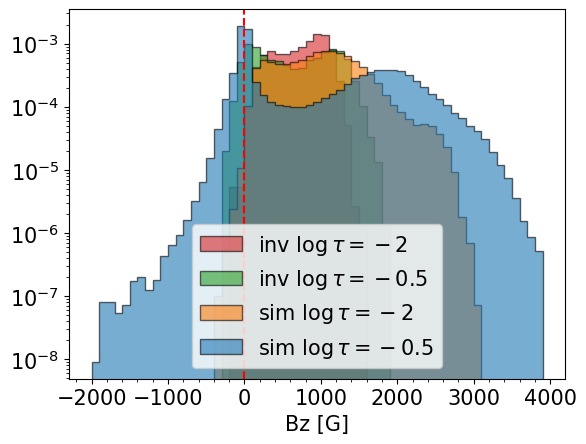

In [23]:
xbins = np.arange(-2000,4000,100)
plt.hist([Bz[plage[:,0],plage[:,1],15].flatten(),Bz[plage[:,0],plage[:,1],30].flatten(),-atm[20,8,plage_o[:,0],plage_o[:,1],15],-atm[20,8,plage_o[:,0],plage_o[:,1],30]],bins=xbins,histtype='stepfilled',alpha=0.6,label=[r'sim $\log \tau=-0.5$',r'sim $\log \tau=-2$',r'inv $\log \tau=-0.5$',r'inv $\log \tau=-2$'],
         density = [[1/plage.shape[0]]*plage.shape[0],[1/plage.shape[0]]*plage.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel('Bz [G]')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.eps',bbox_inches='tight')
plt.yscale('log')

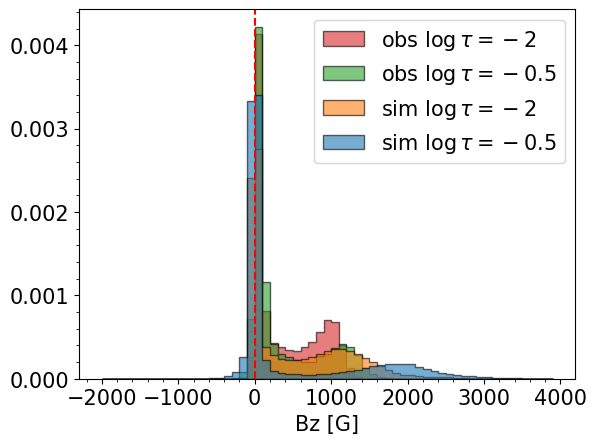

In [32]:
plt.hist([Bz[:,:,15].flatten(),Bz[:,:,30].flatten(),-atm[20,8,:,:,15].flatten(),-atm[20,8,:,:,30].flatten()],bins=xbins,histtype='stepfilled',alpha=0.6,label=[r'sim $\log \tau=-0.5$',r'sim $\log \tau=-2$',r'obs $\log \tau=-0.5$',r'obs $\log \tau=-2$'],
         density = [[1/Bz.shape[0]**2]*Bz.shape[0]**2,[1/Bz.shape[0]**2]*Bz.shape[0]**2,[1/129/116]*129*116,[1/129/116]*129*116], edgecolor='black')
plt.legend()
plt.xlabel('Bz [G]')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.eps',bbox_inches='tight')
#plt.xscale('symlog')

In [20]:
6e8*6e8

3.6e+17

In [41]:
47/6.5

7.230769230769231

In [42]:
Bz.shape

(1536, 1536, 41)

In [19]:
Bz_bin = Bz.reshape(1536//8,8,1536//8,8,41).mean(axis=(1,3))

In [21]:
B_bin = B.reshape(1536//8,8,1536//8,8,41).mean(axis=(1,3))

In [42]:
from scipy.ndimage import gaussian_filter
Filtered = gaussian_filter(Bz[:,:,15], sigma=(47/2.355/6.5))

In [ ]:
imgstacked = np.concatenate([Bz[:,:,:], Bz[:,:,:]],axis=1)
imgstacked_bin = np.concatenate([Bz_bin[:,:,:], Bz_bin[:,:,:]],axis=1)

In [22]:
B_stacked = np.concatenate([B[:,:,:], B[:,:,:]],axis=1)
B_stacked_bin = np.concatenate([B_bin[:,:,:], B_bin[:,:,:]],axis=1)

In [33]:
c6 = imgstacked[230:1152,1305:2150,15] < -50
c7 = B_stacked[230:1152,1305:2150,30] > 300
oppo0 = np.argwhere(c6 & c7)

In [57]:
c6 = imgstacked_bin[28:114,163:268,15] < -50
c7 = B_stacked_bin[28:114,163:268,30] > 300
oppo1 = np.argwhere(c6 & c7)

In [95]:
c8 = B_stacked[230:1152,1305:2150,30] > 300
plage0 = np.argwhere(c8)

In [92]:
c8 = B_stacked[691:1536,1459:2380,30] > 300
plage0 = np.argwhere(c8)

In [64]:
c8 = B_stacked_bin[28:114,163:268,30] > 300
plage1 = np.argwhere(c8)

In [ ]:
imgstacked[230:1152,1305:2150,15].shape

(0, 845)

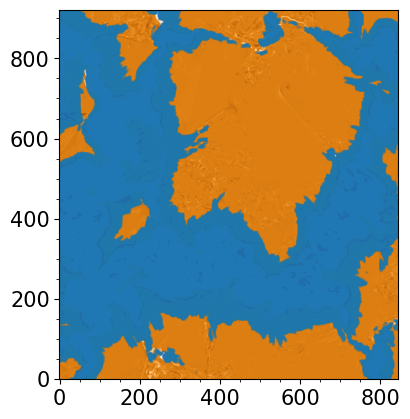

In [70]:
plt.imshow(imgstacked[230:1152,1305:2150,15],origin='lower',cmap='PuOr')
plt.scatter(plage0[:,1],plage0[:,0],s=1,alpha=0.1)

In [74]:
np.mean(imgstacked[230:1152,1305:2150,15])

519.1434876999817

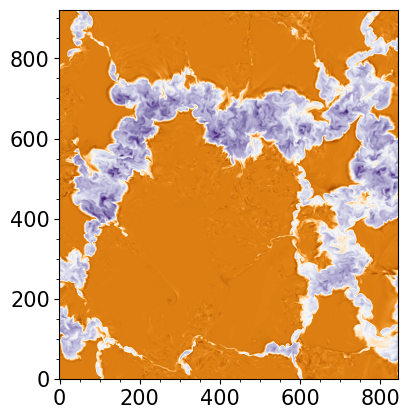

In [53]:
plt.imshow(imgstacked[1152:230:-1,2150:1305:-1,15],origin='lower',cmap='PuOr')

In [39]:
2150//8

268

In [30]:
14/10*1536

2150.3999999999996

In [ ]:
xbins = np.arange(-1000,3000,100)
plt.hist([imgstacked[plage0[:,0]]])

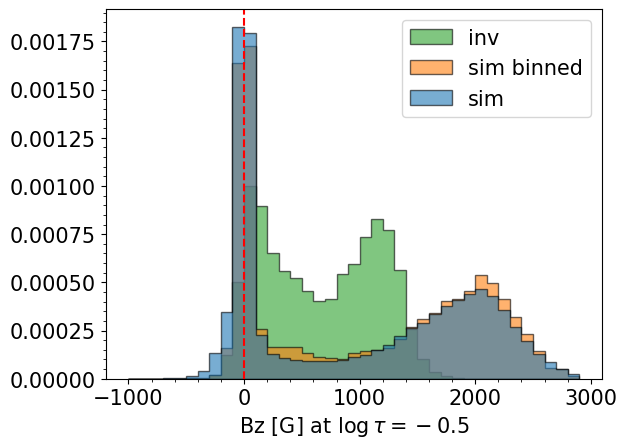

In [120]:
xbins = np.arange(-1000,3000,100)
plt.hist([imgstacked[plage0[:,0]+230,plage0[:,1]+1305,15].flatten(),imgstacked_bin[plage1[:,0]+28,plage1[:,1]+163,15],-atm[20,8,plage_o[:,0],plage_o[:,1],15]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/plage0.shape[0]]*plage0.shape[0],[1/plage1.shape[0]]*plage1.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-0.5$')
plt.axvline(0,color='red',ls='--')
plt.savefig('hist_bz.png',bbox_inches='tight')
#plt.yscale('log')

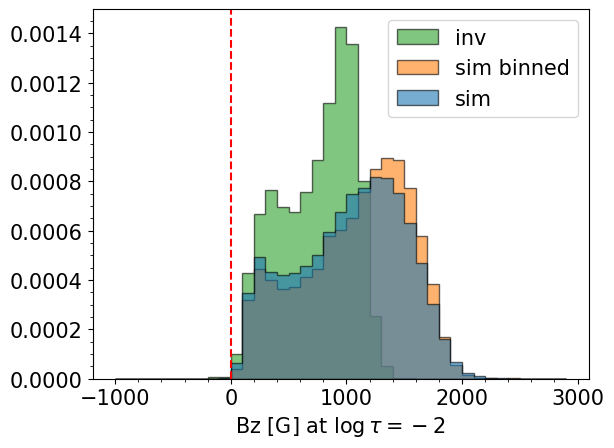

In [121]:
xbins = np.arange(-1000,3000,100)
plt.hist([imgstacked[plage0[:,0]+230,plage0[:,1]+1305,30].flatten(),imgstacked_bin[plage1[:,0]+28,plage1[:,1]+163,30],-atm[20,8,plage_o[:,0],plage_o[:,1],30]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/plage0.shape[0]]*plage0.shape[0],[1/plage1.shape[0]]*plage1.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-2$')
plt.axvline(0,color='red',ls='--')
plt.savefig('hist_bz2.png',bbox_inches='tight')
#plt.yscale('log')

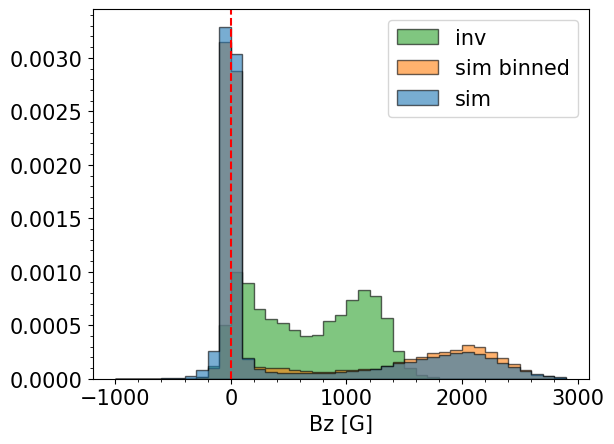

In [142]:
xbins = np.arange(-1000,3000,100)
plt.hist([imgstacked[230:1152,1305:2150,15].flatten(),imgstacked_bin[28:114,163:268,15].flatten(),-atm[20,8,plage_o[:,0],plage_o[:,1],15]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'], edgecolor='black',
            density = [[1/plage0.shape[0]]*plage0.shape[0],[1/plage1.shape[0]]*plage1.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]])
plt.legend()
plt.xlabel('Bz [G]')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.eps',bbox_inches='tight')
#plt.yscale('log')

In [52]:
plt.rc('font', size = 12)

(14.0, 8.5)

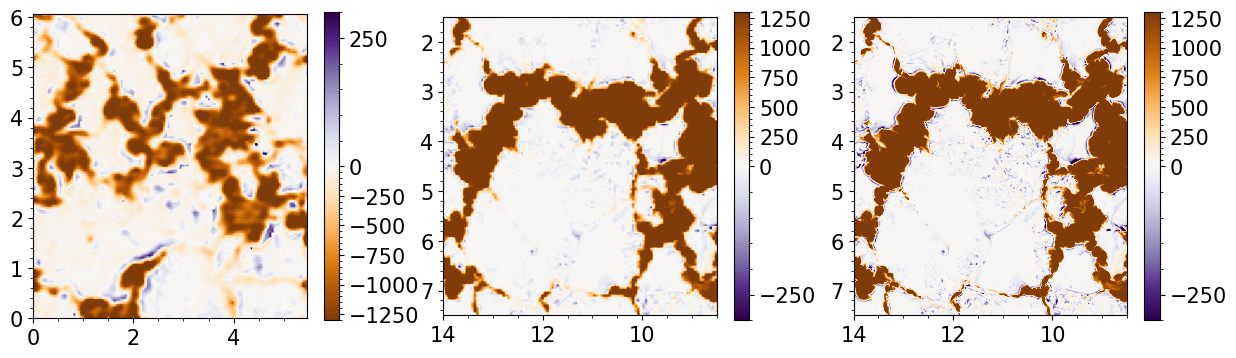

In [80]:
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(atm[0,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1300),extent=[0,116*0.047,0,129*0.047])
plt.colorbar()
#plt.contour(atm[0,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.subplot(132)
plt.imshow(imgstacked_bin,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,10])
plt.colorbar()
plt.xlim([14,8.5])
plt.ylim([7.5,1.5])
#plt.contour(imgstacked_bin,levels=[-50],extent=[0,20,0,10])
plt.subplot(133)
plt.imshow(imgstacked,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,10])
plt.colorbar()
plt.ylim([7.5,1.5])
plt.xlim([14,8.5])
#plt.contour(imgstacked,levels=[-50],extent=[0,20,0,10])

(14.0, 8.5)

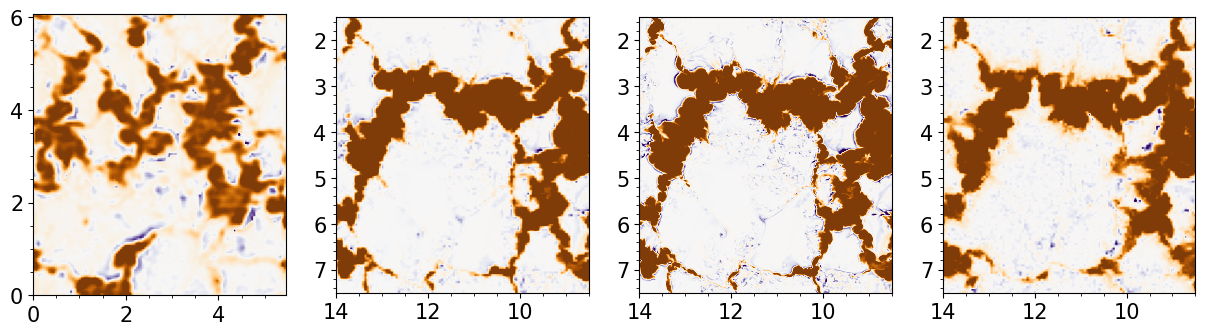

In [138]:
plt.figure(figsize=(15,4))
plt.subplot(141)
plt.imshow(atm[0,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1300),extent=[0,116*0.047,0,129*0.047])
#plt.colorbar()
#plt.contour(atm[0,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.subplot(142)
plt.imshow(imgstacked_bin[:,:,15],origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,10])
#plt.colorbar()
plt.xlim([14,8.5])
plt.ylim([7.5,1.5])
#plt.contour(imgstacked_bin,levels=[-50],extent=[0,20,0,10])
plt.subplot(143)
plt.imshow(imgstacked[:,:,15],origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,10])
#plt.colorbar()
plt.ylim([7.5,1.5])
plt.xlim([14,8.5])
#plt.contour(imgstacked,levels=[-50],extent=[0,20,0,10])
plt.subplot(144)
plt.imshow(stacked_bin[:,:,15],origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,10])
#plt.colorbar()
plt.ylim([7.5,1.5])
plt.xlim([14,8.5])

-361.4855090911067


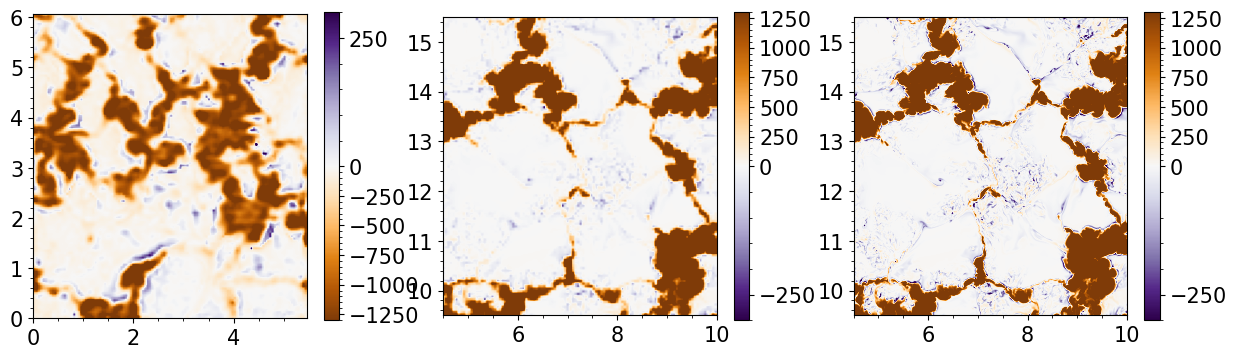

In [91]:
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(atm[0,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1300),extent=[0,116*0.047,0,129*0.047])
plt.colorbar()
#plt.contour(atm[0,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.subplot(132)
plt.imshow(imgstacked_bin[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
plt.colorbar()
plt.xlim([4.5,10])
plt.ylim([9.5,15.5])
#plt.contour(imgstacked_bin,levels=[-50],extent=[0,20,0,10])
plt.subplot(133)
plt.imshow(imgstacked[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
plt.colorbar()
plt.xlim([4.5,10])
plt.ylim([9.5,15.5])
#plt.contour(imgstacked,levels=[-50],extent=[0,20,0,10])
print(np.mean(atm[0,8,:,:,15]))

In [86]:
15.5*1536//10

2380.0

In [88]:
print(np.mean(imgstacked[691:1536,1459:2380,15]))

345.2675273193747


In [134]:
stacked_bin = np.concatenate([Bz1[:,:,:],Bz1[:,:,:]],axis=1)

In [30]:
imgstacked_bin = np.concatenate([Bz_bin[:,:,15], Bz_bin[:,:,15]],axis=1)

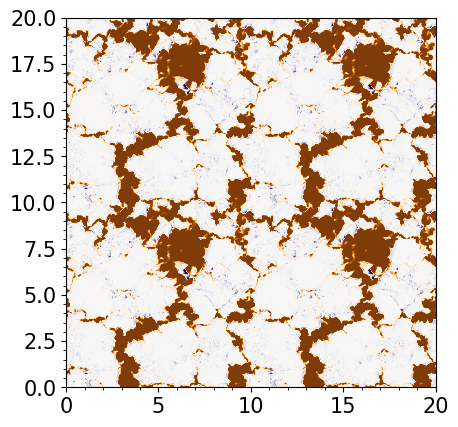

In [139]:
# I want to put two Bz next to each other: 
imgstacked0 = np.concatenate([Bz[:,:,15], Bz[:,:,15]],axis=1)
imgstacked2 = np.concatenate([imgstacked0[:,:], imgstacked0[:,:]],axis=0)

plt.imshow(imgstacked2.T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,20,0,20])

Text(0.5, 1.0, 'Bz [G]')

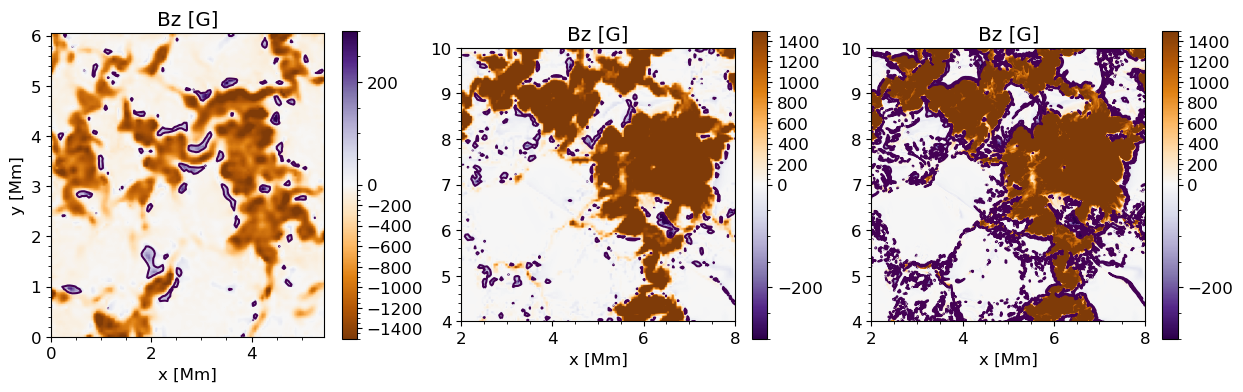

In [69]:
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(atm[60,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1500),extent=[0,116*0.047,0,129*0.047])
plt.colorbar()
plt.contour(atm[60,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.ylabel('y [Mm]')
plt.xlabel('x [Mm]')
plt.title('Bz [G]')
plt.subplot(132)
plt.imshow(Bz_bin[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1500,vcenter=0,vmin=-300),extent=[0,10,0,10])
plt.colorbar()
plt.contour(Bz_bin[:,:,15].T,levels=[-50],extent=[0,10,0,10])
plt.xlim([2,8])
plt.ylim([4,10])
plt.xlabel('x [Mm]')
plt.title('Bz [G]')
plt.subplot(133)
plt.imshow(Bz[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1500,vcenter=0,vmin=-300),extent=[0,10,0,10])
plt.colorbar()
plt.contour(Bz[:,:,15].T,levels=[-50],extent=[0,10,0,10])
plt.xlim([2,8])
plt.ylim([4,10])
plt.xlabel('x [Mm]')
plt.title('Bz [G]')
#plt.savefig('Bz_oppo.eps',bbox_inches='tight')

Text(0.5, 1.0, 'Bz [G]')

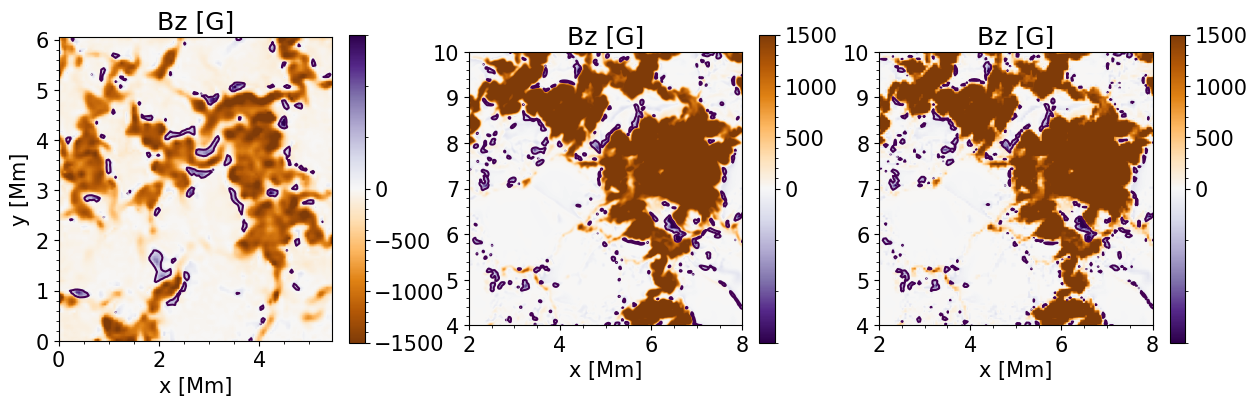

In [122]:
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.imshow(atm[60,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1500),extent=[0,116*0.047,0,129*0.047])
plt.colorbar()
plt.contour(atm[60,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.ylabel('y [Mm]')
plt.xlabel('x [Mm]')
plt.title('Bz [G]')
plt.subplot(132)
plt.imshow(Filtered[:,:].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1500,vcenter=0,vmin=-300),extent=[0,10,0,10])
plt.colorbar()
plt.contour(Filtered[:,:].T,levels=[-50],extent=[0,10,0,10])
plt.xlim([2,8])
plt.ylim([4,10])
plt.xlabel('x [Mm]')
plt.title('Bz [G]')
plt.subplot(133)
plt.imshow(Bz_bin[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1500,vcenter=0,vmin=-300),extent=[0,10,0,10])
plt.colorbar()
plt.contour(Bz_bin[:,:,15].T,levels=[-50],extent=[0,10,0,10])
plt.xlim([2,8])
plt.ylim([4,10])
plt.xlabel('x [Mm]')
plt.title('Bz [G]')

In [ ]:
plt.hist(atm[0,8,:,:,15])

In [19]:
116*47*129*47*1e10

3.3055476e+17

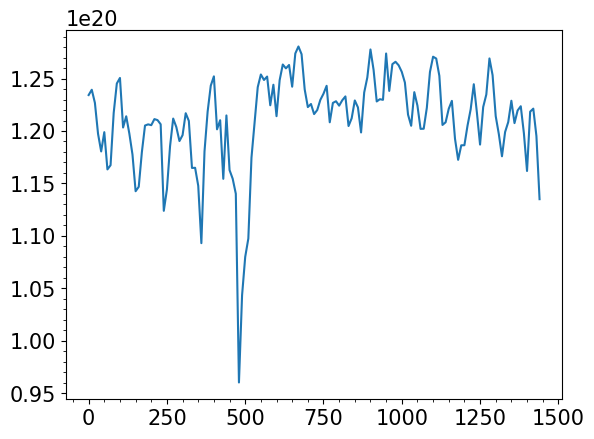

In [17]:
plt.plot(t, np.mean(np.abs(atm[:,8,:,:,10]),axis=(1,2))*(116*47*129*47*1e10))

## Vz

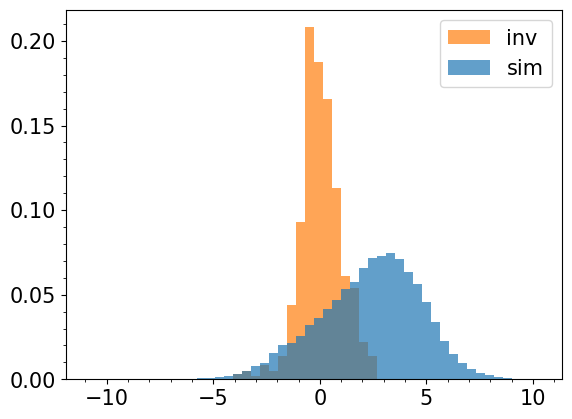

In [19]:
plt.hist([Vz[oppo[:,0],oppo[:,1],10]/1e5,atm[1,5,oppo_o[:,0],oppo_o[:,1],10]/1e5],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/oppo.shape[0]]*oppo.shape[0],[1/oppo_o.shape[0]]*oppo_o.shape[0]])
plt.legend()

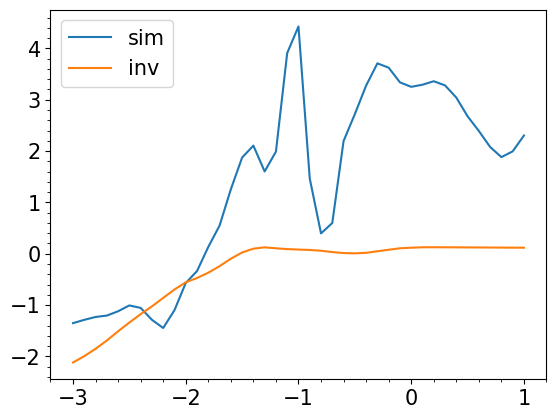

In [25]:
plt.plot(tau_common,Vz[oppo[100,0],oppo[100,1],:]/1e5,label='sim')
plt.plot(tau_common,atm[1,5,oppo_o[100,0],oppo_o[100,1],:41]/1e5,label='inv')
plt.legend()

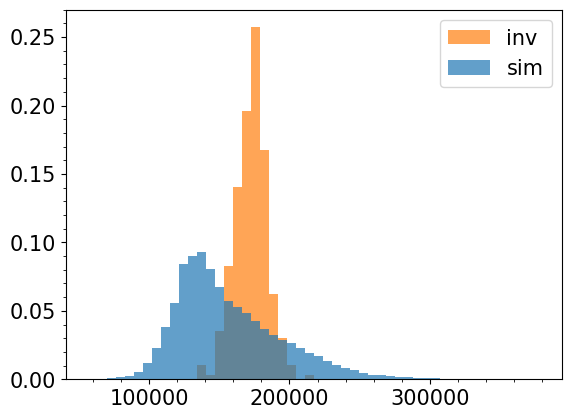

In [22]:
plt.hist([P[oppo[:,0],oppo[:,1],10],atm[1,2,oppo_o[:,0],oppo_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/oppo.shape[0]]*oppo.shape[0],[1/oppo_o.shape[0]]*oppo_o.shape[0]])
plt.legend()

## plasma $\beta$

$\beta = \frac{P_g}{\frac{B^2}{8\pi}}$

In [114]:
P[10,10,10]

28648.039356253645

In [115]:
atm[1,2,10,10,30]

18033.993966078684

In [105]:
beta_o = 8*np.pi*atm[1,2,:,:,:]/(atm[1,6,:,:,:]**2+atm[1,7,:,:,:]**2+atm[1,8,:,:,:]**2)

In [130]:
beta = 8*np.pi*P[:,:,:]/B[:,:,:]**2

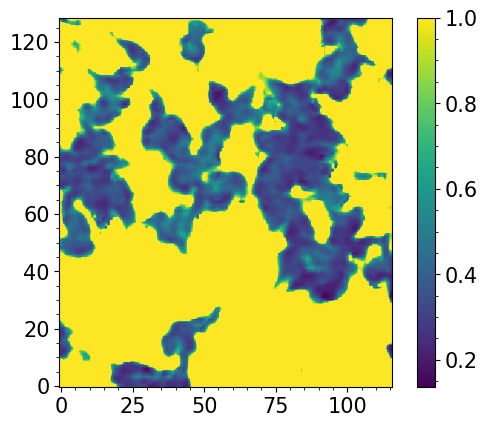

In [131]:
plt.imshow(beta_o[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()

Text(0.5, 0.98, 'plasma $\\beta$ at $\\tau=0.01$')

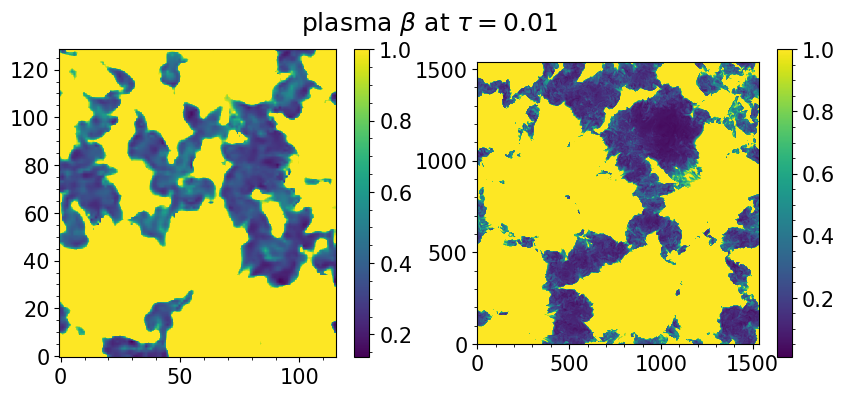

In [138]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(beta_o[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()
plt.subplot(122)
plt.imshow(beta[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()
plt.suptitle(r'plasma $\beta$ at $\tau=0.01$')

(0.0, 0.0001)

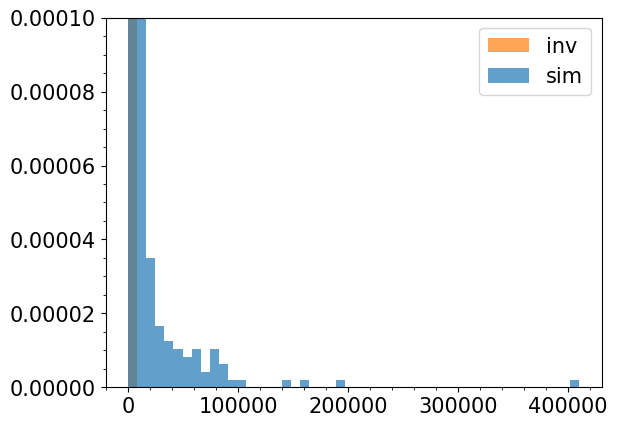

In [151]:
plt.hist([beta[core[:,0],core[:,1],30],beta_o[core_o[:,0],core_o[:,1],30]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()
plt.ylim(0,0.0001)

In [153]:
print(np.mean(beta[core[:,0],core[:,1],30]))
print(np.mean(beta_o[core_o[:,0],core_o[:,1],30]))

12.401941334440423
0.359583962379677


## opposite polarity pixels in time series

In [20]:
atm.shape

(145, 10, 116, 129, 51)

In [21]:
oppo_counts = []
Bz_o_mean = []
for t in tqdm(range(145)):
    c6 = atm[t,8,:,:,10] > 50
    c7 = atm[t,8,:,:,30] <-200
    #c7 = np.sqrt(atm[t,8,:,:,30]**2+atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2) > 300
    oppo_o = np.argwhere(c6 & c7)
    oppo_counts.append(oppo_o.shape[0])
    Bz_o_mean.append(np.mean(atm[t,8,oppo_o[:,0],oppo_o[:,1],10]))


100%|██████████| 145/145 [00:46<00:00,  3.13it/s]


In [24]:
oppo_counts = np.array(oppo_counts)

In [54]:
t = np.arange(145)*10

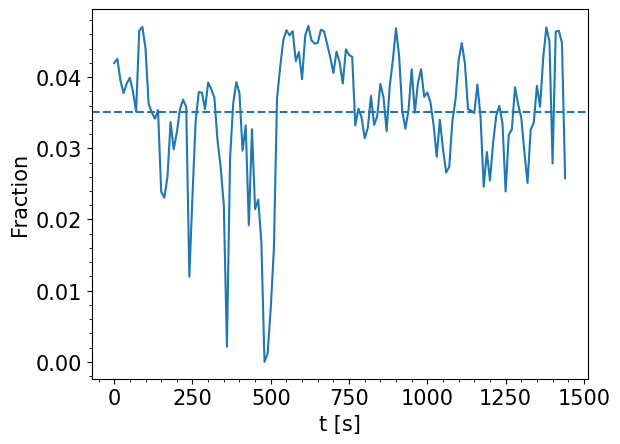

In [103]:
plt.plot(t,np.array(oppo_counts)/129./116.)
plt.xlabel('t [s]')
plt.ylabel('Fraction')
plt.axhline(np.mean(np.array(oppo_counts)/129./116.),ls='--')

In [62]:
np.mean(np.array(oppo_counts)/129./116.)

0.035138585478712125

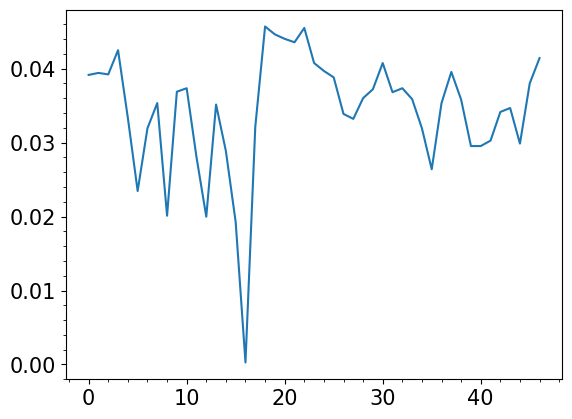

In [49]:
plt.plot(oppo_counts/129/116)

In [48]:
np.mean(oppo_counts)/129/116

0.034319245622117196

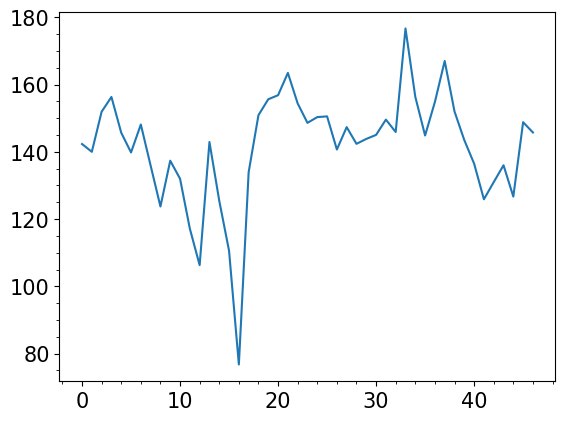

In [52]:
plt.plot(Bz_o_mean)

In [53]:
np.mean(Bz_o_mean)

141.65937600433207

In [22]:
muramdir = '/dat/milic/MURaM_400G_plage_pore/'

In [23]:
nx = 1536
ny = 1536
nz = 1056
nsnaps = 650

In [24]:
Bz0 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_1.000_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))
Bz1 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_0.100_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))
Bz2 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_0.010_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))

In [25]:
Bz0_bin = Bz0.reshape(650,1536//8,8,1536//8,8).mean(axis=(2,4))
Bz2_bin = Bz2.reshape(650,1536//8,8,1536//8,8).mean(axis=(2,4))

In [ ]:
# interpolate to get log tau = -0.5
#  

In [26]:
from tqdm import tqdm
oppo_s_counts = [] 
Bz_s_mean = []
for t in tqdm(range(650)):
    c6 = Bz0[t,:,:]*np.sqrt(4*np.pi) < -50
    c7 = Bz2[t,:,:]*np.sqrt(4*np.pi) > 200
    oppo = np.argwhere(c6 & c7)
    oppo_s_counts.append(oppo.shape[0])
    Bz_s_mean.append(np.mean(Bz0[t,oppo[:,0],oppo[:,1]]))
oppo_s_counts = np.array(oppo_s_counts)

100%|██████████| 650/650 [00:08<00:00, 79.09it/s]


In [52]:
oppo_sb_counts = [] 
Bz_sb_mean = []
for t in tqdm(range(650)):
    c6 = Bz0_bin[t,:,:]*np.sqrt(4*np.pi) < -50
    c7 = Bz2_bin[t,:,:]*np.sqrt(4*np.pi) > 200
    oppo = np.argwhere(c6 & c7)
    oppo_sb_counts.append(oppo.shape[0])
    Bz_sb_mean.append(np.mean(Bz0_bin[t,oppo[:,0],oppo[:,1]]))
oppo_sb_counts = np.array(oppo_sb_counts)

100%|██████████| 650/650 [00:00<00:00, 5300.93it/s]


In [36]:
ts = np.arange(650)*1.43

In [48]:
oppo_sb_counts = [] 
#Bz_sb_mean = []
for t in tqdm(range(650)):
    c6 = gaussian_filter(Bz0[t,:,:], sigma=(52/2.355/6.5))*np.sqrt(4*np.pi) < -50
    c7 = gaussian_filter(Bz2[t,:,:], sigma=(52/2.355/6.5))*np.sqrt(4*np.pi) > 200
    oppo = np.argwhere(c6 & c7)
    oppo_sb_counts.append(oppo.shape[0])
    #Bz_sb_mean.append(np.mean(gaussian_filter(Bz0[t,:,:], sigma=(47/2.355/6.5))[t,oppo[:,0],oppo[:,1]]))
oppo_sb_counts = np.array(oppo_sb_counts)

100%|██████████| 650/650 [01:51<00:00,  5.82it/s]


In [110]:
1536/8

192.0

In [128]:
8*6.5

52.0

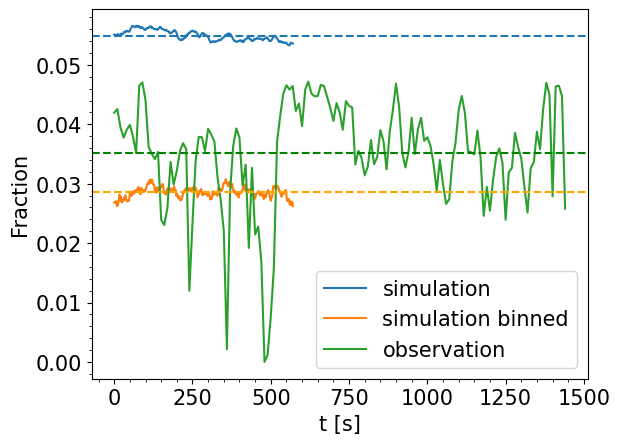

In [55]:
plt.plot(ts[:400],oppo_s_counts[:400]/1536./1536.,label='simulation')
plt.plot(ts[:400],oppo_sb_counts[:400]/192./192.,label='simulation binned')
plt.plot(t,np.array(oppo_counts)/129./116.,label='observation')
plt.xlabel('t [s]')
plt.ylabel('Fraction')
plt.axhline(np.mean(oppo_s_counts[:400])/1536/1536,ls='--')
plt.axhline(np.mean(oppo_sb_counts[:400])/192/192,ls='--',color='orange')
plt.axhline(np.mean(np.array(oppo_counts)/129./116.),ls='--',color='green')
plt.legend()

In [34]:
print(plage.shape[0]/1536/1536)
print(plage_o.shape[0]/116/129)

0.46607335408528644
0.49746057203956157


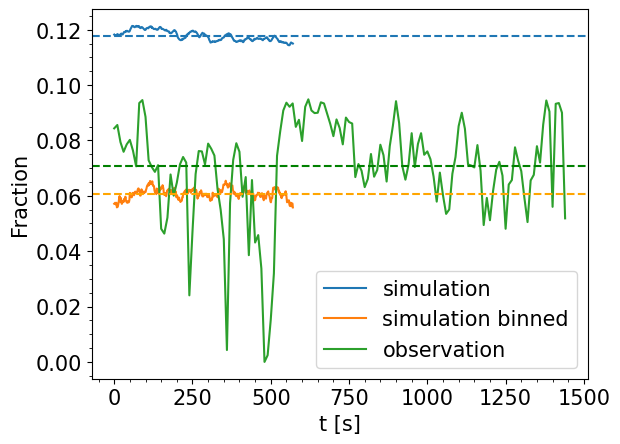

In [41]:
plt.plot(ts[:400],oppo_s_counts[:400]/plage.shape[0],label='simulation')
plt.plot(ts[:400],oppo_sb_counts[:400]/192./192./0.47,label='simulation binned')
plt.plot(t,np.array(oppo_counts)/plage_o.shape[0],label='observation')
plt.xlabel('t [s]')
plt.ylabel('Fraction')
plt.axhline(np.mean(oppo_s_counts[:400])/plage.shape[0],ls='--')
plt.axhline(np.mean(oppo_sb_counts[:400])/192/192/0.47,ls='--',color='orange')
plt.axhline(np.mean(np.array(oppo_counts)/plage_o.shape[0]),ls='--',color='green')
plt.legend()

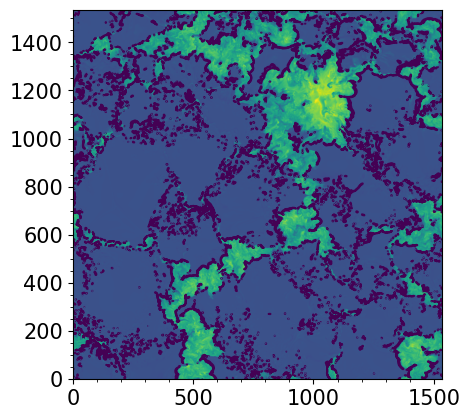

In [76]:
plt.imshow(Bz0[500,:,:].T,origin='lower')
plt.contour(Bz0[500,:,:].T,levels=[-50])

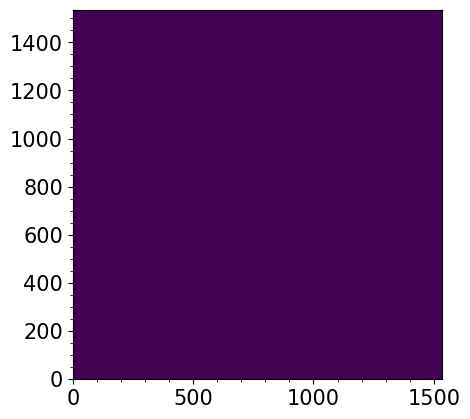

In [107]:
plt.imshow(Bz2[500,:,:].T,origin='lower')
plt.contour(Bz2[500,:,:].T,levels=[200])

In [33]:
np.mean(oppo_s_counts[:400])/1536/1536

0.05494690259297689

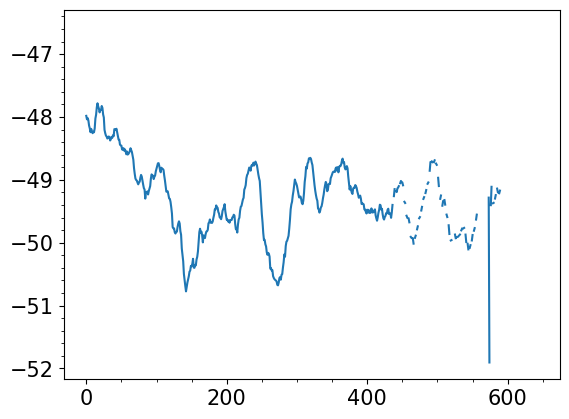

In [89]:
plt.plot(Bz_s_mean[:])

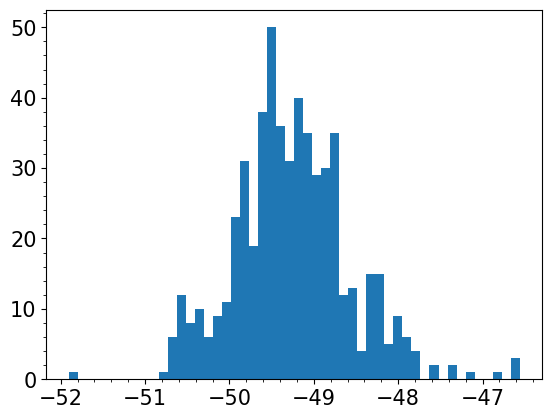

In [90]:
plt.hist(Bz_s_mean,bins=50)
plt.show()

In [91]:
np.nanmean(Bz_s_mean)*np.sqrt(4*np.pi)

-174.58274214852622

In [92]:
Bz_s_mean = np.array(Bz_s_mean)

In [104]:
freqs

array([ 0.        ,  0.04255319,  0.08510638,  0.12765957,  0.17021277,
        0.21276596,  0.25531915,  0.29787234,  0.34042553,  0.38297872,
        0.42553191,  0.46808511,  0.5106383 ,  0.55319149,  0.59574468,
        0.63829787,  0.68085106,  0.72340426,  0.76595745,  0.80851064,
        0.85106383,  0.89361702,  0.93617021,  0.9787234 , -0.9787234 ,
       -0.93617021, -0.89361702, -0.85106383, -0.80851064, -0.76595745,
       -0.72340426, -0.68085106, -0.63829787, -0.59574468, -0.55319149,
       -0.5106383 , -0.46808511, -0.42553191, -0.38297872, -0.34042553,
       -0.29787234, -0.25531915, -0.21276596, -0.17021277, -0.12765957,
       -0.08510638, -0.04255319])

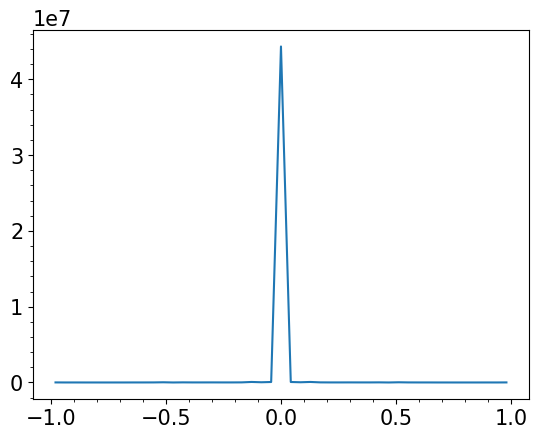

In [103]:
fourier = np.fft.fft(Bz_o_mean)
ps = np.abs(fourier)**2
freqs = np.fft.fftfreq(47,0.5)
idx = np.argsort(freqs)
plt.plot(freqs[idx],ps[idx])

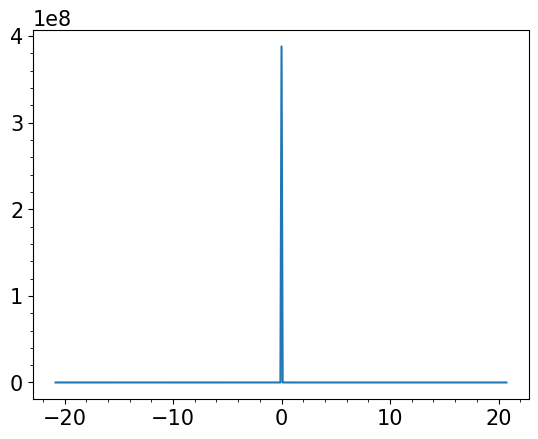

In [101]:
fourier = np.fft.fft(Bz_s_mean[:400])
ps = np.abs(fourier)**2
freqs = np.fft.fftfreq(400,1.44/60)
idx = np.argsort(freqs)
plt.plot(freqs[idx],ps[idx])
#plt.xlim([-1,1])

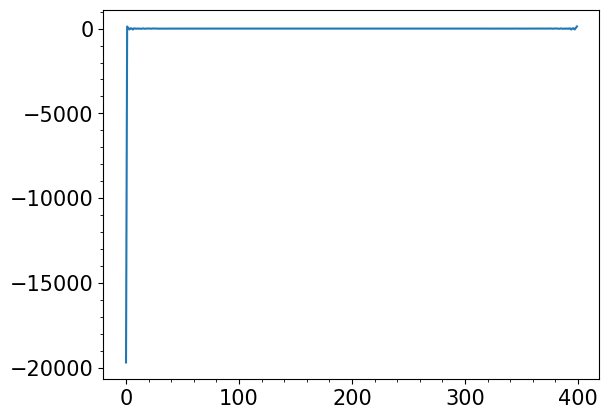

In [99]:
plt.plot(fourier)